# Insect Micro-CT → NPZ Conversion and Visualization

This notebook converts the **Insect micro-CT** dataset (paired `.tif` image/mask files)
into the unified `.npz` format used by the Prompt U-Net pipeline.

## Dataset overview
- **Source**: Toulkeridou et al., *Automated segmentation of insect anatomy from micro-CT images using deep learning*, bioRxiv 2021.
- **Images**: 2D micro-CT cross-sections at 520×520 px (uint8), organised by specimen.
- **Masks**: Same-resolution TIFF files where brain pixels retain their intensity and background = 0. Converted to binary (0/1) here.
- **Naming convention**: `{SpeciesName}_{idx}.tif` / `{SpeciesName}_{idx}_mask.tif`
- **Label map**: `0` = Background, `1` = Brain

Slices are stacked along the Z-axis per specimen, yielding one 3-D volume `(Z, 520, 520)` per specimen.

## 0. Imports & path setup

In [1]:
import sys
import os
import numpy as np
from pathlib import Path

# Add project root to sys.path
project_root = str(Path().resolve().parent.parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from data.test_data.insect_to_npz import process_insect_dataset, LABEL_MAP
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices

print("Project root:", project_root)
print("Label map:", LABEL_MAP)

Project root: C:\Users\Paul\Desktop\Studium\prompt-unet
Label map: {0: 'Background', 1: 'Brain'}


## 1. Quick data inspection

Before converting, let's peek at a few raw TIFF pairs to understand the pixel distributions.

In [ ]:
# import tifffile
# import matplotlib.pyplot as plt

# # Adjust this to your data directory
# script_dir = os.path.abspath('')  # notebook directory
# data_dir = os.path.join(script_dir, 'Insect', 'training')

# print("Data directory:", data_dir)
# print("Exists:", os.path.isdir(data_dir))

# # Grab a sample image/mask pair
# sample_img_path  = os.path.join(data_dir, 'Acromyrmex_versicolor_100.tif')
# sample_mask_path = os.path.join(data_dir, 'Acromyrmex_versicolor_100_mask.tif')

# img  = tifffile.imread(sample_img_path)
# mask = tifffile.imread(sample_mask_path)
# binary_mask = (mask > 0).astype(np.uint8)

# print(f"Image  shape={img.shape} dtype={img.dtype}  min={img.min()} max={img.max()}")
# print(f"Mask   shape={mask.shape} dtype={mask.dtype}  nonzero fraction={(mask > 0).mean():.3f}")
# print(f"Binary mask unique values: {np.unique(binary_mask)}")

# fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# axes[0].imshow(img,         cmap='gray'); axes[0].set_title('Raw Image (micro-CT)');  axes[0].axis('off')
# axes[1].imshow(mask,        cmap='gray'); axes[1].set_title('Raw Mask (pixel intensities)'); axes[1].axis('off')
# axes[2].imshow(binary_mask, cmap='gray'); axes[2].set_title('Binary Mask (>0 threshold)');  axes[2].axis('off')
# plt.tight_layout()
# plt.show()

## 2. Convert the dataset to .npz

Run `process_insect_dataset` to stack all specimen slices and save them.

> **Note**: With ~35 000 image pairs this may take a few minutes.

In [ ]:
script_dir = os.path.abspath('')  # notebook directory
data_dir = os.path.join(script_dir, 'Insect', 'training')

output_name = 'insect_ct'
out_path    = os.path.join(script_dir, output_name)

if os.path.isdir(data_dir):
    process_insect_dataset(
        data_dir=data_dir,
        output_path=out_path,
        mask_threshold=0,   # pixels > 0 are brain
    )
else:
    print(f"Data directory not found: {data_dir}")
    print("Please ensure the Insect/training folder exists relative to this notebook.")

## 3. Load the .npz and inspect via DataGenerator

In [3]:
output_name = 'insect_ct'
npz_relative = f'data/test_data/{output_name}.npz'
full_npz_path = os.path.join(project_root, npz_relative)

print("Loading:", full_npz_path)

dg = DataGenerator(DataLoader_npz([full_npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids

print(f"\nLoaded {len(all_ids)} specimens.")
print("First 10 IDs:", all_ids[:10])

Loading: C:\Users\Paul\Desktop\Studium\prompt-unet\data/test_data/insect_ct.npz

Loading NPZ dataset(s)…
Loaded 40 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\insect_ct.npz

Final dataset size: 40 patients.


Loaded 40 specimens.
First 10 IDs: ['insect_ct_Pogonomyrmex_pima', 'insect_ct_Atta_texana3', 'insect_ct_Dolichoderus_mariae3', 'insect_ct_Pheidole_rhea', 'insect_ct_Tetramorium_immigrans2', 'insect_ct_Crematogaster_pimicola3', 'insect_ct_Dorymyrmex_insanus_group-l2', 'insect_ct_Temnothorax_curvispinosus', 'insect_ct_Temnothorax_curvispinosus3', 'insect_ct_Cephalotes_atratus3']


In [4]:
# Inspect a single specimen
sample_id = all_ids[0]
entry     = dg.dataloader.dataset[sample_id]

vol  = entry['image']           # (Z, 520, 520) float32
segs = entry['segmentations']   # (Z, 520, 520) uint8  or list

# segmentations may be a single array or a list
seg = segs[0] if isinstance(segs, (list, tuple)) else segs

print(f"Specimen  : {sample_id}")
print(f"Image     : shape={vol.shape}  dtype={vol.dtype}")
print(f"Segmentation: shape={seg.shape}  dtype={seg.dtype}")
print(f"Brain voxels: {seg.sum()} / {seg.size}  ({100*seg.mean():.2f} %)")
print(f"Modality  : {entry['modality']}")

Specimen  : insect_ct_Pogonomyrmex_pima
Image     : shape=(300, 520, 520)  dtype=float32
Segmentation: shape=(300, 520, 520)  dtype=uint8
Brain voxels: 17185770 / 81120000  (21.19 %)
Modality  : micro-CT


## 4. Visualize: 9-slice overview grid

We plot 9 equally spaced slices along the Z-axis together with their brain masks overlaid.

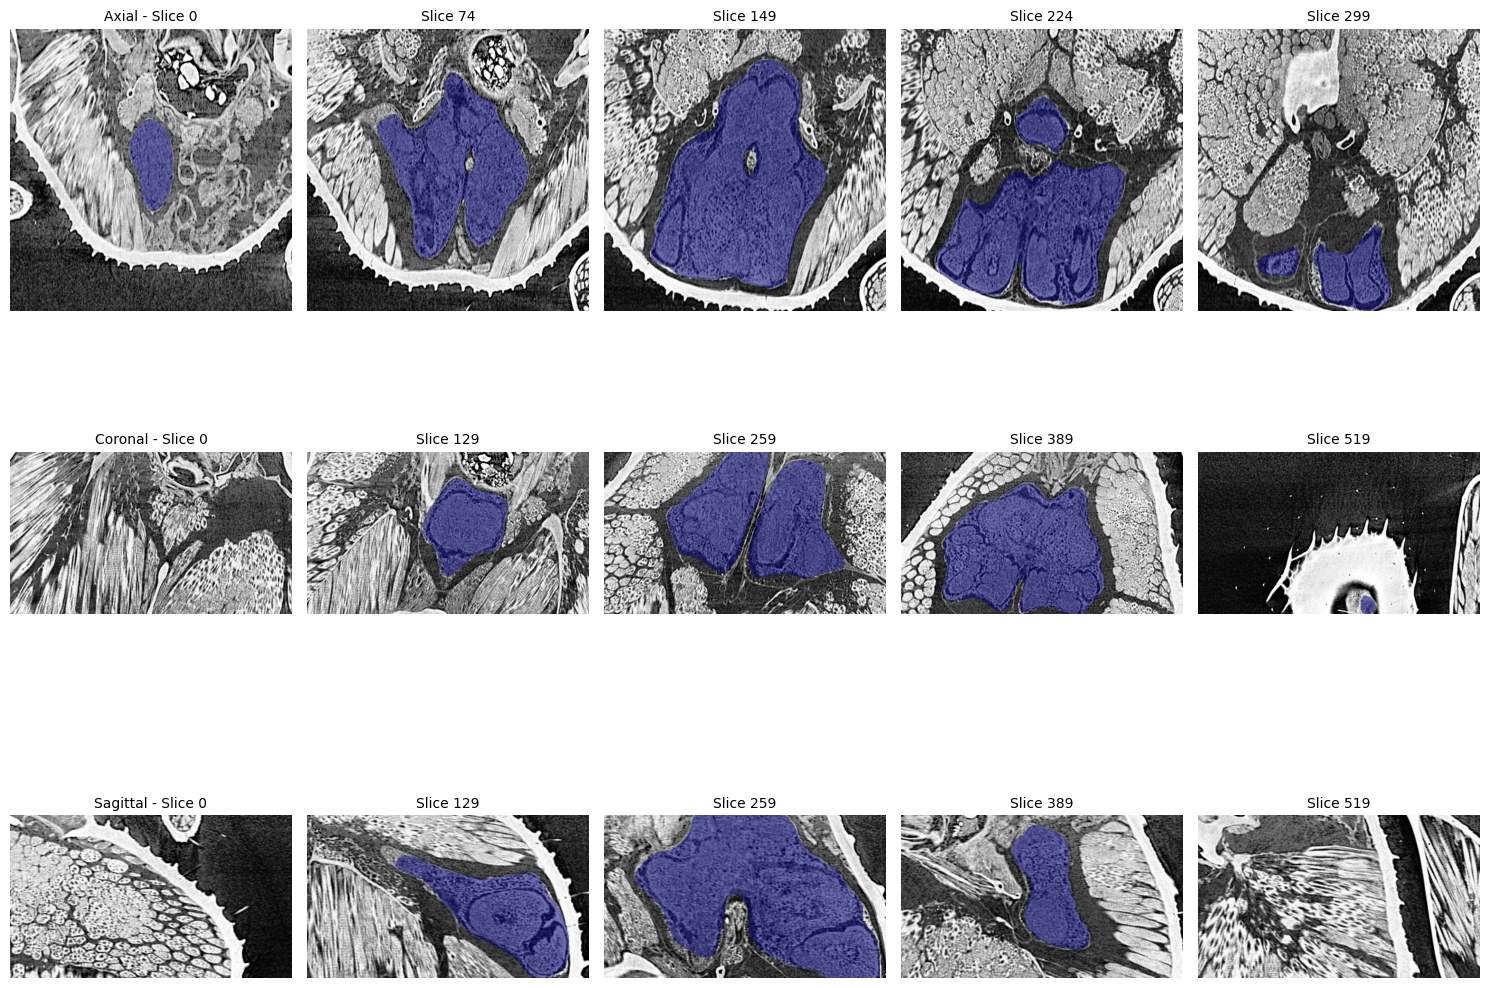

In [5]:
plot_vol_slices(vol, seg)

## 5. Visualize: side-by-side comparison across specimens

Pick the middle slice for each of the first 5 specimens to compare brain sizes.

In [8]:
from matplotlib import pyplot as plt

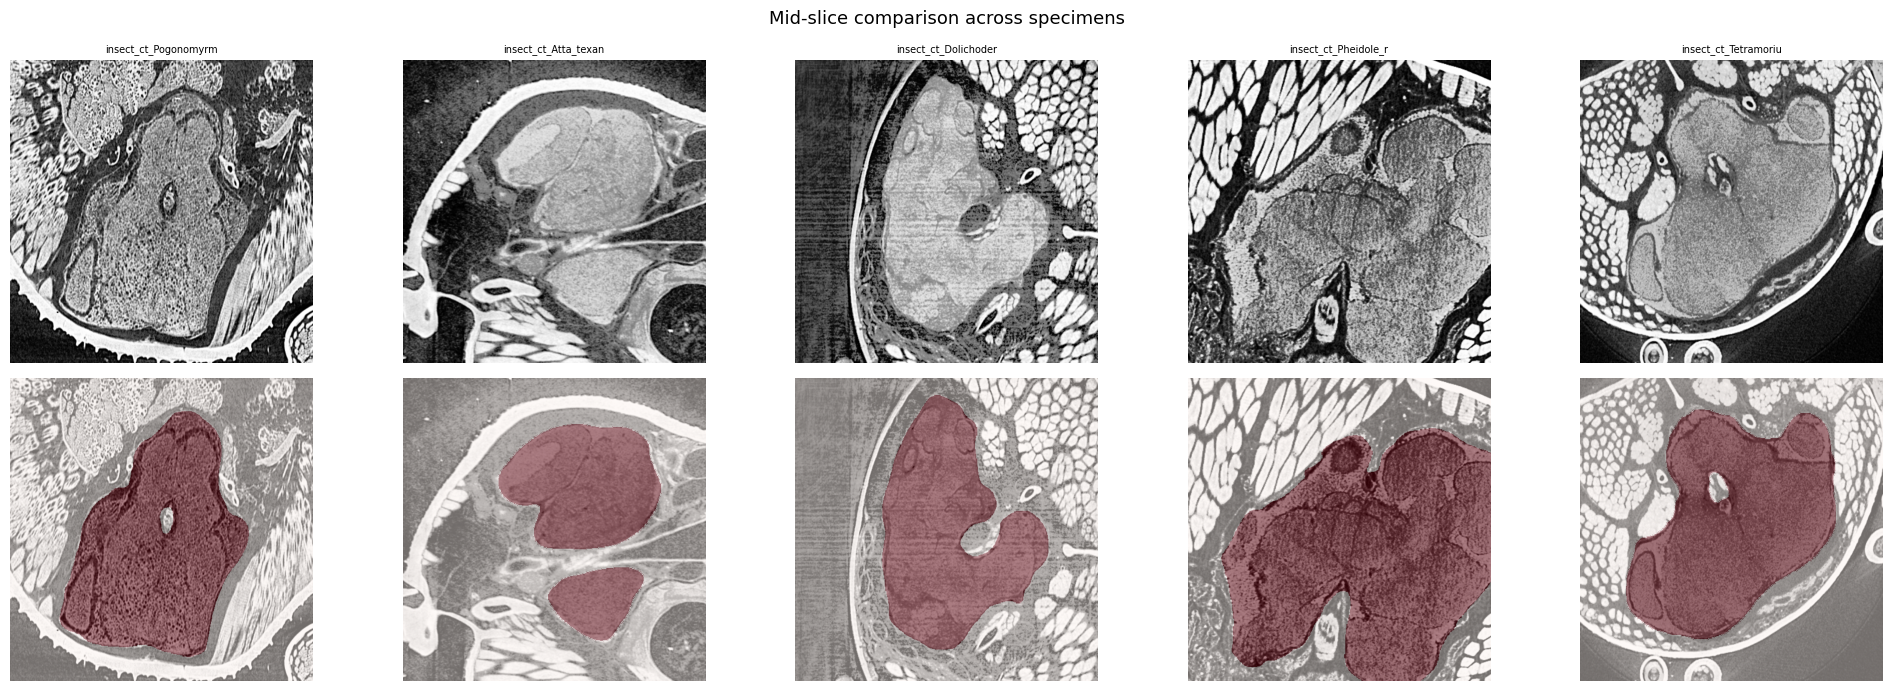

In [9]:
n_specimens = min(5, len(all_ids))
fig, axes = plt.subplots(2, n_specimens, figsize=(20, 7))
fig.suptitle("Mid-slice comparison across specimens", fontsize=13)

for col, sid in enumerate(all_ids[:n_specimens]):
    e = dg.dataloader.dataset[sid]
    v = e['image']
    s = e['segmentations']
    if isinstance(s, (list, tuple)):
        s = s[0]

    mid_z = v.shape[0] // 2

    axes[0, col].imshow(v[mid_z], cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(sid[:20], fontsize=7)
    axes[0, col].axis('off')

    axes[1, col].imshow(v[mid_z], cmap='gray', vmin=0, vmax=255)
    axes[1, col].imshow(s[mid_z], cmap='Reds', alpha=0.45, vmin=0, vmax=1)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=9)
axes[1, 0].set_ylabel('Image + Brain mask', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Dataset statistics summary

Number of specimens        : 40
Slices per specimen        : min=99 max=448 mean=294.0
Brain voxel fraction       : min=6.85%  max=39.17%  mean=21.47%


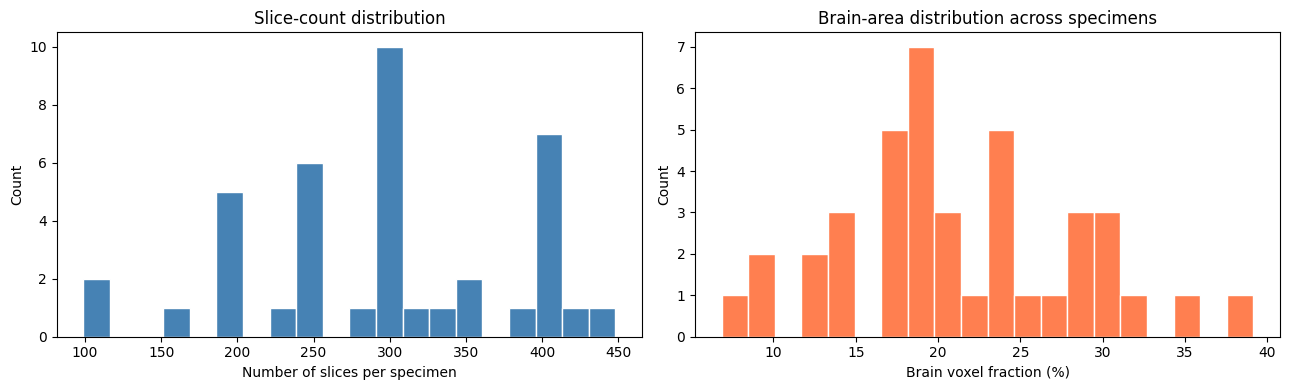

In [10]:
slice_counts = []
brain_fracs  = []

for sid in all_ids:
    e = dg.dataloader.dataset[sid]
    v = e['image']
    s = e['segmentations']
    if isinstance(s, (list, tuple)):
        s = s[0]
    slice_counts.append(v.shape[0])
    brain_fracs.append(s.mean())

print(f"Number of specimens        : {len(all_ids)}")
print(f"Slices per specimen        : min={min(slice_counts)} max={max(slice_counts)} mean={np.mean(slice_counts):.1f}")
print(f"Brain voxel fraction       : min={min(brain_fracs)*100:.2f}%  max={max(brain_fracs)*100:.2f}%  mean={np.mean(brain_fracs)*100:.2f}%")

# Histogram of slice counts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(slice_counts, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Number of slices per specimen")
axes[0].set_ylabel("Count")
axes[0].set_title("Slice-count distribution")

axes[1].hist([f*100 for f in brain_fracs], bins=20, color='coral', edgecolor='white')
axes[1].set_xlabel("Brain voxel fraction (%)")
axes[1].set_ylabel("Count")
axes[1].set_title("Brain-area distribution across specimens")

plt.tight_layout()
plt.show()